In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import calendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

In [2]:
data = pd.read_csv('Min_Temp_In_Melbourne.csv')

In [3]:
data.head()

,Date,Daily minimum temperatures
0,01-01-1981,20.7
1,01-02-1981,17.9
2,01-03-1981,18.8
3,01-04-1981,14.6
4,01-05-1981,15.8


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        3650 non-null   object
 1   Daily minimum temperatures  3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB


In [5]:
data.shape

(3650, 2)

In [6]:
data['ds'] = pd.date_range(start = '1981/01/01', periods = len(data), freq='D')

In [7]:
data.drop(['Date'], axis=1, inplace=True)

In [8]:
data.rename(columns = {'Daily minimum temperatures':'y'}, inplace=True)

In [9]:
data = data[['ds', 'y']]

In [10]:
data.isnull().sum()

ds    0
y     0
dtype: int64

In [11]:
data.isna().sum()

ds    0
y     0
dtype: int64

In [12]:
data.isin([0]).sum()

ds    0
y     0
dtype: int64

In [13]:
data['y'].unique()

array(['20.7', '17.9', '18.8', '14.6', '15.8', '17.4', '21.8', '20',
       '16.2', '13.3', '16.7', '21.5', '25', '20.6', '24.8', '17.7',
       '15.5', '18.2', '12.1', '14.4', '16', '16.5', '18.7', '19.4',
       '17.2', '15.1', '15.4', '15.3', '21.9', '19.9', '16.6', '16.8',
       '17.1', '15', '13.7', '13.9', '18.3', '22', '22.1', '21.2', '18.4',
       '16.1', '15.7', '18.5', '16.9', '17.5', '17.8', '18.6', '17',
       '14.3', '11.4', '16.3', '11.8', '12.2', '14.7', '11.3', '10.6',
       '11.7', '14.2', '11.2', '8.1', '8', '8.8', '13.4', '10.9', '11',
       '14.5', '18.1', '10', '14.9', '15.9', '13', '7.6', '11.5', '13.5',
       '12.4', '13.2', '13.8', '9', '9.8', '8.9', '7.4', '9.9', '9.3',
       '8.6', '11.9', '14', '12', '10.5', '10.7', '10.1', '5.3', '6.6',
       '8.5', '5.9', '3.2', '2.1', '3.4', '5.4', '9.6', '12.3', '12.6',
       '12.8', '11.6', '5.7', '7.1', '2.5', '3.5', '4.6', '7.7', '10.4',
       '9.2', '6.1', '2.7', '4.3', '6.3', '3.8', '4.4', '4.8', '5.8',
   

In [14]:
data.shape

(3650, 2)

In [15]:
data['y'] = data['y'].str.replace('?','',regex=False).astype(float)

In [16]:
data['y'].unique()

array([20.7, 17.9, 18.8, 14.6, 15.8, 17.4, 21.8, 20. , 16.2, 13.3, 16.7,
       21.5, 25. , 20.6, 24.8, 17.7, 15.5, 18.2, 12.1, 14.4, 16. , 16.5,
       18.7, 19.4, 17.2, 15.1, 15.4, 15.3, 21.9, 19.9, 16.6, 16.8, 17.1,
       15. , 13.7, 13.9, 18.3, 22. , 22.1, 21.2, 18.4, 16.1, 15.7, 18.5,
       16.9, 17.5, 17.8, 18.6, 17. , 14.3, 11.4, 16.3, 11.8, 12.2, 14.7,
       11.3, 10.6, 11.7, 14.2, 11.2,  8.1,  8. ,  8.8, 13.4, 10.9, 11. ,
       14.5, 18.1, 10. , 14.9, 15.9, 13. ,  7.6, 11.5, 13.5, 12.4, 13.2,
       13.8,  9. ,  9.8,  8.9,  7.4,  9.9,  9.3,  8.6, 11.9, 14. , 12. ,
       10.5, 10.7, 10.1,  5.3,  6.6,  8.5,  5.9,  3.2,  2.1,  3.4,  5.4,
        9.6, 12.3, 12.6, 12.8, 11.6,  5.7,  7.1,  2.5,  3.5,  4.6,  7.7,
       10.4,  9.2,  6.1,  2.7,  4.3,  6.3,  3.8,  4.4,  4.8,  5.8,  6.2,
        7.3, 10.2,  9.5,  6.5,  7. ,  8.3,  6.8,  7.2,  5. ,  6.9,  5.2,
        3. ,  5.6,  7.9, 10.3,  9.7, 12.5,  3.9,  6. ,  5.5,  7.5,  7.8,
       14.1, 12.9,  9.1,  8.4, 13.6,  9.4, 14.8, 16

<Axes: >

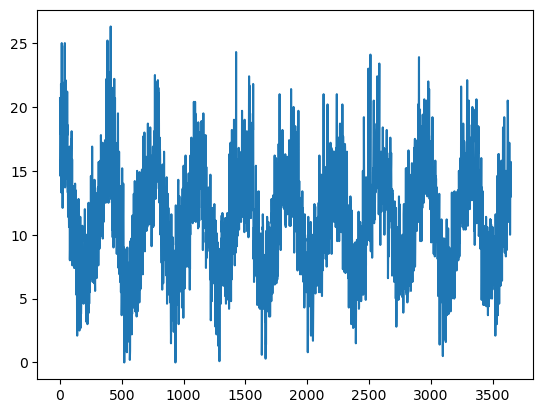

In [17]:
data['y'].plot()

In [18]:
model = Prophet()
model.fit(data)

19:28:52 - cmdstanpy - INFO - Chain [1] start processing
19:28:52 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [20]:
data.tail()

,ds,y
3645,1990-12-25,14.0
3646,1990-12-26,13.6
3647,1990-12-27,13.5
3648,1990-12-28,15.7
3649,1990-12-29,13.0


In [21]:
future = model.make_future_dataframe(periods=365)
future.tail()

,ds
4010,1991-12-25
4011,1991-12-26
4012,1991-12-27
4013,1991-12-28
4014,1991-12-29


In [22]:
predictions = model.predict(future)
predictions.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1981-01-01,11.862720,11.672650,18.726312,11.862720,11.862720,3.236360,3.236360,3.236360,-0.161733,-0.161733,-0.161733,3.398094,3.398094,3.398094,0.0,0.0,0.0,15.099081
1,1981-01-02,11.860851,11.761538,18.965325,11.860851,11.860851,3.479903,3.479903,3.479903,-0.003268,-0.003268,-0.003268,3.483171,3.483171,3.483171,0.0,0.0,0.0,15.340754
2,1981-01-03,11.858982,11.658307,18.580937,11.858982,11.858982,3.406585,3.406585,3.406585,-0.159363,-0.159363,-0.159363,3.565947,3.565947,3.565947,0.0,0.0,0.0,15.265567
3,1981-01-04,11.857113,11.899995,18.595468,11.857113,11.857113,3.494197,3.494197,3.494197,-0.150838,-0.150838,-0.150838,3.645035,3.645035,3.645035,0.0,0.0,0.0,15.351309
4,1981-01-05,11.855244,12.265845,18.968682,11.855244,11.855244,3.793821,3.793821,3.793821,0.074700,0.074700,0.074700,3.719121,3.719121,3.719121,0.0,0.0,0.0,15.649065


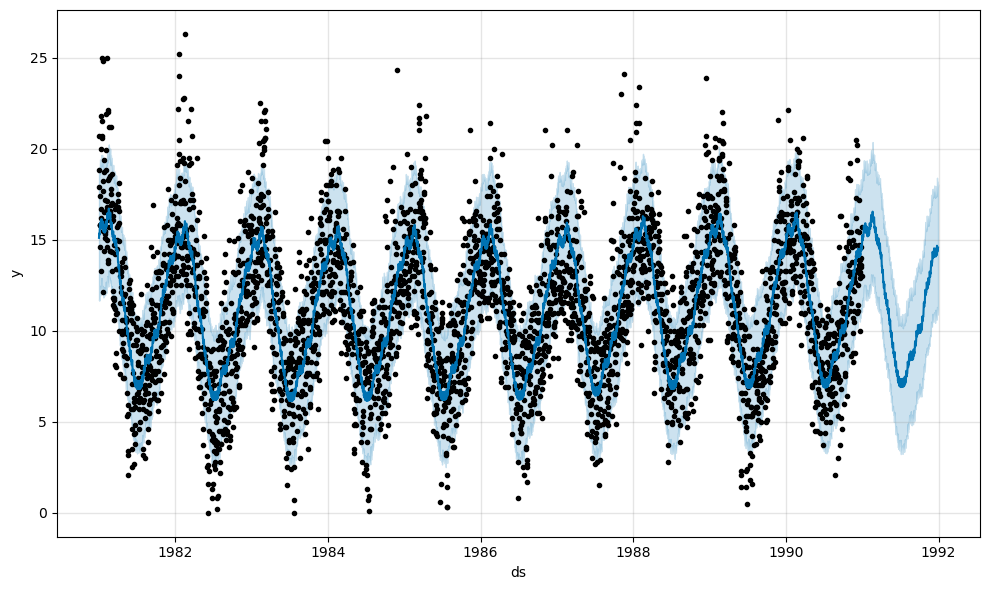

In [28]:
model.plot(predictions)
plt.savefig('prediction.png', bbox_inches='tight')
plt.show();

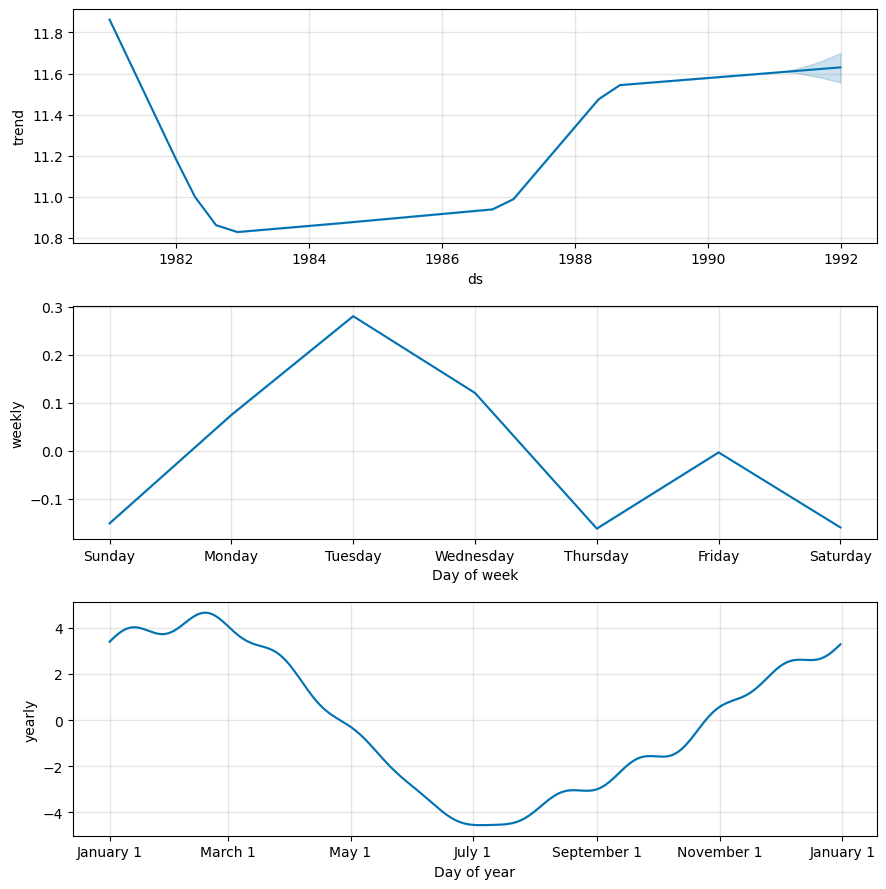

In [29]:
model.plot_components(predictions)
plt.savefig('trend_decomposition.png',bbox_inches='tight')
plt.show();

In [25]:
# initial = '1125' : first 3 years of data used for training
# period = '180 days' : after every 180 days the model creates a new cutoff, retraining from start to that cutoff
# horizon = '365 days' : at each cutoff point the model forecasts 1 year ahead and compares with the actual values
data_cv = cross_validation(model, initial = '730 days', period ='180 days', horizon = '365 days')
data_cv.head()

  0%|          | 0/15 [00:00<?, ?it/s]

19:28:54 - cmdstanpy - INFO - Chain [1] start processing
19:28:54 - cmdstanpy - INFO - Chain [1] done processing
19:28:54 - cmdstanpy - INFO - Chain [1] start processing
19:28:54 - cmdstanpy - INFO - Chain [1] done processing
19:28:55 - cmdstanpy - INFO - Chain [1] start processing
19:28:55 - cmdstanpy - INFO - Chain [1] done processing
19:28:55 - cmdstanpy - INFO - Chain [1] start processing
19:28:55 - cmdstanpy - INFO - Chain [1] done processing
19:28:55 - cmdstanpy - INFO - Chain [1] start processing
19:28:56 - cmdstanpy - INFO - Chain [1] done processing
19:28:56 - cmdstanpy - INFO - Chain [1] start processing
19:28:56 - cmdstanpy - INFO - Chain [1] done processing
19:28:56 - cmdstanpy - INFO - Chain [1] start processing
19:28:57 - cmdstanpy - INFO - Chain [1] done processing
19:28:57 - cmdstanpy - INFO - Chain [1] start processing
19:28:57 - cmdstanpy - INFO - Chain [1] done processing
19:28:57 - cmdstanpy - INFO - Chain [1] start processing
19:28:58 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1983-02-05,15.252966,11.834919,19.045342,14.9,1983-02-04
1,1983-02-06,15.299800,11.704618,18.802443,16.2,1983-02-04
2,1983-02-07,15.630719,11.952521,19.394762,20.3,1983-02-04
3,1983-02-08,15.665055,12.033070,19.268871,22.5,1983-02-04
4,1983-02-09,15.634955,12.001945,19.022656,17.2,1983-02-04


In [26]:
data_p = performance_metrics(data_cv)
data_p.head()

,horizon,mse,rmse,mae,mdape,smape,coverage
0,37 days,7.798826,2.792638,2.165193,0.160867,0.211422,0.787325
1,38 days,7.751892,2.784222,2.160246,0.160867,0.209892,0.791712
2,39 days,7.718269,2.778177,2.153649,0.161917,0.208677,0.791956
3,40 days,7.509363,2.740322,2.124757,0.158600,0.205747,0.798172
4,41 days,7.491279,2.737020,2.125075,0.157817,0.205899,0.796466


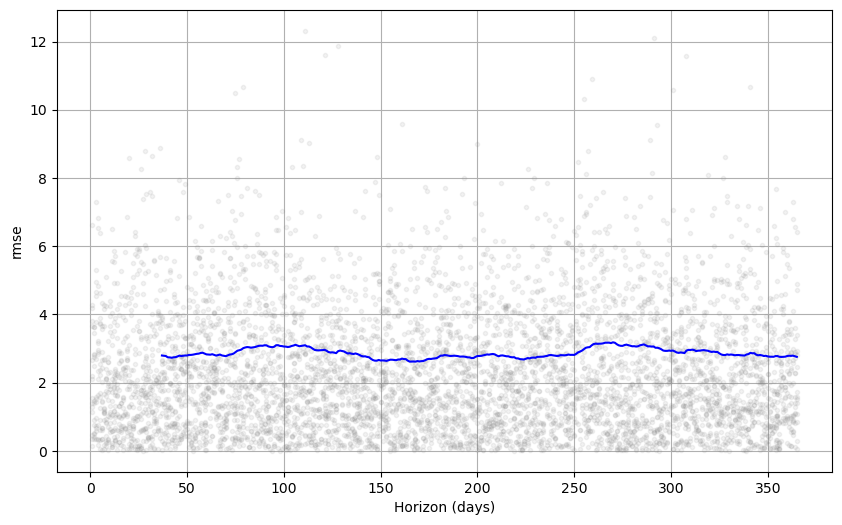

In [30]:
plot_cross_validation_metric(data_cv, metric='rmse')
plt.savefig('rmse_plot.png', bbox_inches='tight')
plt.show();